# Phase 5a — Interpretability & Model Export

**Project:** Robust Respiratory Sound Classification under Noise and Domain Shift using Audio Spectrogram Transformers

### Overview

This notebook:

1. Loads the final trained AST checkpoint for inference only.
2. Verifies the model’s patch geometry to ensure correct heatmap alignment.
3. Generates **Attention Rollout** and **Grad-CAM** spectrogram heatmaps.
4. Compares explanations for correct/misclassified samples and clean/noisy inputs.
5. Performs a **randomized-weight sanity check** to assess whether explanations depend on learned representations.
6. Exports an **FP16 checkpoint** (`ast_lung_fp16.pt`) and verifies prediction parity with the FP32 model.

> **Interpretation note:** ICBHI provides cycle-level labels, not event-level localization labels. Therefore, these heatmaps are **qualitative explanations**, not validated localization results. Attention maps should not be interpreted as proof of model reasoning.

### Required Inputs

* `01-data-preparation` — `splits/test.csv`
* `03A-ast-finetuning-ce` — `waveform_cache/`
* Final model checkpoint — configured through `CHECKPOINT_PATH`

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import torch
from transformers import ASTFeatureExtractor, ASTForAudioClassification

from scipy.signal import butter, sosfiltfilt


plt.rcParams["figure.dpi"] = 110

## **1. Config**

In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

PHASE1_DIR = Path("/kaggle/input/notebooks/praveshsubba/01-data-preparation/icbhi_processed")
SPLIT_DIR = PHASE1_DIR / "splits"

CE_NOTEBOOK_DIR = Path("/kaggle/input/notebooks/praveshsubba/03a-ast-finetuning-ce")
WAVEFORM_CACHE_DIR = CE_NOTEBOOK_DIR / "waveform_cache"


CHECKPOINT_PATH = Path("/kaggle/input/notebooks/praveshsubba/03d-ast-augmentation-ablation/checkpoints/ast_both_best.pt")

OUT_DIR = Path("/kaggle/working"); FIG_DIR = OUT_DIR / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)

LABELS = ["normal", "crackle", "wheeze", "both"]
AST_CHECKPOINT = "MIT/ast-finetuned-audioset-10-10-0.4593"

N_PROFILE_PER_CLASS = 15       # cycles per class for the frequency-profile figure
NOISE_SNRS_DB = [None, 10, 0]  # for the clean-vs-noisy comparison


# ---- Audio / AST geometry constants (must match Phase 1-4 preprocessing) ----
TARGET_SR = 16000
LOWCUT, HIGHCUT = 50, 8000
WINDOW_S = 8.0

N_MELS = 128              # AST input: 1024 time frames x 128 mel bins
N_FRAMES_PAD = 1024       # HF ASTFeatureExtractor pads/truncates to this
PATCH = 16                # 16x16 patches ...
STRIDE = 10               # ... with stride 10 (overlap of 6)
F_PATCHES = (N_MELS - PATCH) // STRIDE + 1          # 12 patches along frequency
T_PATCHES = (N_FRAMES_PAD - PATCH) // STRIDE + 1    # 101 patches along time
N_PATCH_TOKENS = F_PATCHES * T_PATCHES              # 1212
N_SPECIAL_TOKENS = 2      # [CLS] + distillation token come first in the sequence
FRAME_SHIFT_S = 0.010     # 10 ms hop


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
assert CHECKPOINT_PATH.exists(), f"Checkpoint not found: {CHECKPOINT_PATH}"


Device: cuda


## **2. Helper Functions**

These NumPy-based helper functions are shared with the demo application and were **unit-tested locally** before being integrated into the notebook.

The tests verify that:

* The AST patch grid is **12 frequency × 101 time**, with **2 special tokens**, giving **1214 total tokens**.
* Attention rollout rows remain properly normalized.
* A single activated patch maps back to the correct **mel-frequency and time-frame region**.
* Patch tokens use **frequency-major flattening**:

`idx = f × 101 + t`


In [3]:
def bandpass_filter(signal, sr, lowcut=LOWCUT, highcut=HIGHCUT, order=5):
    nyquist = sr / 2.0
    highcut = min(highcut, nyquist * 0.99)
    sos = butter(order, [lowcut, highcut], btype="band", fs=sr, output="sos")
    return sosfiltfilt(sos, signal).astype(np.float32)


def pad_or_truncate(signal, sr, target_duration=WINDOW_S):
    target_length = int(target_duration * sr)
    current_length = len(signal)
    if current_length == target_length:
        return signal
    if current_length > target_length:
        start = (current_length - target_length) // 2
        return signal[start : start + target_length]
    n_repeats = int(np.ceil(target_length / current_length))
    return np.tile(signal, n_repeats)[:target_length]


def n_real_frames(n_samples, sr=TARGET_SR):
    """Number of spectrogram frames that come from real audio (the rest of the
    1024 is padding). Kaldi-style fbank: 25 ms window, 10 ms shift."""
    frame_len = int(0.025 * sr)
    shift = int(0.010 * sr)
    n = 1 + (n_samples - frame_len) // shift
    return int(min(max(n, 1), N_FRAMES_PAD))


def attention_rollout(attn_mats):
    """Abnar & Zuidema (2020). attn_mats: list of (T, T) head-averaged attention
    matrices, ordered first layer -> last layer. Adds the residual connection
    (0.5*A + 0.5*I), re-normalizes rows, and multiplies through the layers."""
    T = attn_mats[0].shape[0]
    eye = np.eye(T, dtype=np.float64)
    rollout = eye.copy()
    for A in attn_mats:
        A_hat = 0.5 * A.astype(np.float64) + 0.5 * eye
        A_hat = A_hat / A_hat.sum(axis=-1, keepdims=True)
        rollout = A_hat @ rollout
    return rollout


def rollout_to_patch_grid(rollout):
    """AST pools the [CLS] and distillation tokens (average) for classification,
    so use both rows. Patch tokens are ordered frequency-major: idx = f*T_PATCHES + t."""
    scores = 0.5 * (rollout[0, N_SPECIAL_TOKENS:] + rollout[1, N_SPECIAL_TOKENS:])
    assert scores.shape[0] == N_PATCH_TOKENS, f"Unexpected token count: {scores.shape[0]}"
    return scores.reshape(F_PATCHES, T_PATCHES)


def patch_grid_to_spectrogram(grid):
    """Overlap-aware mapping of the 12x101 patch grid back onto the 128x1024
    spectrogram: every pixel gets the average score of all patches covering it."""
    canvas = np.zeros((N_MELS, N_FRAMES_PAD), dtype=np.float64)
    counts = np.zeros_like(canvas)
    for f in range(F_PATCHES):
        for t in range(T_PATCHES):
            fs, ts = f * STRIDE, t * STRIDE
            canvas[fs:fs + PATCH, ts:ts + PATCH] += grid[f, t]
            counts[fs:fs + PATCH, ts:ts + PATCH] += 1
    out = np.divide(canvas, counts, out=np.zeros_like(canvas), where=counts > 0)
    # the last few mel rows / frames fall outside every patch -> replicate the edge
    rows = np.where(counts.max(axis=1) > 0)[0]
    cols = np.where(counts.max(axis=0) > 0)[0]
    out[rows[-1] + 1:, :] = out[rows[-1], :]
    out[:, cols[-1] + 1:] = out[:, cols[-1]][:, None]
    return out.astype(np.float32)


def normalize01(x):
    x = np.asarray(x, dtype=np.float32)
    lo, hi = float(x.min()), float(x.max())
    return (x - lo) / (hi - lo + 1e-12)


def make_windows(audio, sr=TARGET_SR, window_s=WINDOW_S, stride_s=4.0):
    """Slice a recording into fixed windows (the model was trained on 8 s cycles).
    Shorter audio is loop-padded (same as training); the tail is always covered."""
    W, S = int(window_s * sr), int(stride_s * sr)
    duration = len(audio) / sr
    if len(audio) <= W:
        return [{"start_s": 0.0, "end_s": duration,
                 "waveform": pad_or_truncate(audio, sr, window_s)}]
    starts = list(range(0, len(audio) - W + 1, S))
    if starts[-1] + W < len(audio):
        starts.append(len(audio) - W)
    return [{"start_s": s / sr, "end_s": s / sr + window_s, "waveform": audio[s:s + W]}
            for s in starts]


## **3. Load test set + cached waveforms**

In [4]:
test_df = pd.read_csv(SPLIT_DIR / "test.csv")

required_cols = {"audio_path", "start", "end", "label"}
missing = required_cols - set(test_df.columns)

assert not missing, f"Missing expected columns: {missing}"

print("Test set:", test_df.shape)


def resolve_waveform_path(row, cache_dir=WAVEFORM_CACHE_DIR):
    cycle_id = (
        f"{Path(row['audio_path']).stem}_"
        f"{float(row['start'])}_"
        f"{float(row['end'])}"
    )

    waveform_path = cache_dir / f"{cycle_id}.npy"

    # Use existing cache only — do not regenerate
    if not waveform_path.exists():
        raise FileNotFoundError(
            f"Cached waveform not found:\n{waveform_path}"
        )

    return str(waveform_path)


test_df["waveform_path"] = [
    resolve_waveform_path(row)
    for _, row in test_df.iterrows()
]

print(f"Resolved {len(test_df)} waveform paths.")
print("All cached waveform paths resolved successfully.")

Test set: (1185, 14)
Resolved 1185 waveform paths.
All cached waveform paths resolved successfully.


## **4. Load the Model with *Eager* Attention**

Recent versions of `transformers` may use fused attention implementations that do not return attention weights.

Because **Attention Rollout requires these attention weights**, the model is explicitly loaded with `attn_implementation="eager"`.

The notebook also verifies that attention weights are actually returned before proceeding with the rollout analysis.


In [5]:
fe = ASTFeatureExtractor.from_pretrained(AST_CHECKPOINT)
id2label = {i: l for i, l in enumerate(LABELS)}; label2id = {l: i for i, l in enumerate(LABELS)}

def build_model():
    kwargs = dict(num_labels=len(LABELS), id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True)
    try:
        return ASTForAudioClassification.from_pretrained(AST_CHECKPOINT, attn_implementation="eager", **kwargs)
    except TypeError:
        return ASTForAudioClassification.from_pretrained(AST_CHECKPOINT, **kwargs)

model = build_model().to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()

def features(waveform):
    return fe(waveform, sampling_rate=TARGET_SR, return_tensors="pt")["input_values"]   # (1, 1024, 128)

# attentions must come back, otherwise rollout is impossible
_x = features(np.load(test_df.iloc[0]["waveform_path"])).to(DEVICE)
with torch.no_grad():
    _out = model(input_values=_x, output_attentions=True)
assert _out.attentions is not None and _out.attentions[0] is not None, (
    "No attention weights returned -- reload with attn_implementation='eager'.")
print("Layers:", len(_out.attentions), "| attention shape per layer:", tuple(_out.attentions[0].shape))
assert _out.attentions[0].shape[-1] == N_PATCH_TOKENS + N_SPECIAL_TOKENS
del _out; torch.cuda.empty_cache()

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([4, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([4])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Layers: 12 | attention shape per layer: (1, 12, 1214, 1214)


## **5. Geometry Sanity Check on the Real Model**

This check verifies that spectrogram coordinates are mapped correctly to AST patch tokens and prevents **silent heatmap transposition errors**.

A small non-zero blob is inserted at **mel bins 60–65** and **frames 500–505** of an otherwise zero-valued input. Only the patch tokens whose **16×16 receptive fields** overlap this blob should differ from the all-zero baseline.


In [6]:
patch_embed = model.audio_spectrogram_transformer.embeddings.patch_embeddings

zero = torch.zeros(1, N_FRAMES_PAD, N_MELS, device=DEVICE)      # (1, 1024 time, 128 mel)
blob = zero.clone(); blob[0, 500:506, 60:66] = 1.0               # time frames 500-505, mel 60-65

with torch.no_grad():
    e0, e1 = patch_embed(zero), patch_embed(blob)                 # (1, 1212, 768)
changed = ((e1 - e0).abs().sum(-1)[0] > 1e-6).nonzero().flatten().tolist()
cells_hit = sorted(divmod(i, T_PATCHES) for i in changed)
print("Grid cells (freq_patch, time_patch) that see the blob:", cells_hit)
assert cells_hit == [(5, 49), (5, 50), (6, 49), (6, 50)], "Token ordering differs from what the helpers assume!"
print("Geometry check passed: tokens are frequency-major, grid is 12 x 101.")

Grid cells (freq_patch, time_patch) that see the blob: [(5, 49), (5, 50), (6, 49), (6, 50)]
Geometry check passed: tokens are frequency-major, grid is 12 x 101.


## **6. Two Explanation Methods**

Two complementary methods are used to analyze the AST model:

* **Attention Rollout:** Aggregates attention across all 12 Transformer layers, including the residual connections, to estimate the influence of each spectrogram patch on the model's pooled representation.

* **Grad-CAM:** Uses gradients of the predicted class score to identify important spectrogram tokens. For the AST, gradients are extracted from the **input to the final Transformer block (`layernorm_before`)**, ensuring that patch-token contributions are captured before the final block outputs only the special tokens used by the classifier.

Together, these methods provide complementary views of which spectrogram regions are associated with the model's predictions.


In [7]:
@torch.no_grad()
def compute_rollout_map(model, x):
    out = model(input_values=x, output_attentions=True)
    mats = [a[0].float().mean(dim=0).cpu().numpy() for a in out.attentions]   # head-average per layer
    probs = out.logits.float().softmax(-1)[0].cpu().numpy()
    rmap = patch_grid_to_spectrogram(rollout_to_patch_grid(attention_rollout(mats)))
    del out; torch.cuda.empty_cache()
    return rmap, probs


def compute_gradcam_map(model, x, target_class=None):
    model.zero_grad(set_to_none=True)
    layer = model.audio_spectrogram_transformer.encoder.layer[-1]
    store = {}
    def hook(module, inputs, output):
        output.retain_grad()
        store["act"] = output
    handle = layer.layernorm_before.register_forward_hook(hook)
    try:
        with torch.enable_grad():
            logits = model(input_values=x).logits
            if target_class is None:
                target_class = int(logits.argmax(-1))
            logits[0, target_class].backward()
    finally:
        handle.remove()
    act = store["act"][0].detach()
    grad = store["act"].grad[0]
    w = grad[N_SPECIAL_TOKENS:].mean(dim=0)                                    # channel weights
    cam = torch.relu(act[N_SPECIAL_TOKENS:] @ w).cpu().numpy()                 # (1212,)
    probs = logits.detach().float().softmax(-1)[0].cpu().numpy()
    model.zero_grad(set_to_none=True)
    return patch_grid_to_spectrogram(cam.reshape(F_PATCHES, T_PATCHES)), probs

## **7. Predict the whole test set (to choose examples)**

In [8]:
def predict_probs(waveforms, batch_size=16):
    probs = []
    for i in range(0, len(waveforms), batch_size):
        batch = fe(waveforms[i:i + batch_size], sampling_rate=TARGET_SR, return_tensors="pt")["input_values"].to(DEVICE)
        with torch.no_grad():
            probs.append(model(input_values=batch).logits.float().softmax(-1).cpu().numpy())
    return np.concatenate(probs)

waves = [np.load(p) for p in test_df["waveform_path"]]
all_probs = predict_probs(waves)
test_df["pred"] = [LABELS[i] for i in all_probs.argmax(1)]
test_df["conf"] = all_probs.max(1)
test_df["correct"] = test_df["pred"] == test_df["label"]
print(f"Cycle-level exact-class accuracy: {test_df['correct'].mean()*100:.1f}%  (NOT the ICBHI Score -- just for picking examples)")
print(pd.crosstab(test_df["label"], test_df["pred"]))

Cycle-level exact-class accuracy: 56.3%  (NOT the ICBHI Score -- just for picking examples)
pred     both  crackle  normal  wheeze
label                                 
both       21        0       3      50
crackle    28       86     147      37
normal     25       61     480     143
wheeze     16        0       8      80


## **8. Plotting helper + heatmaps for chosen examples**

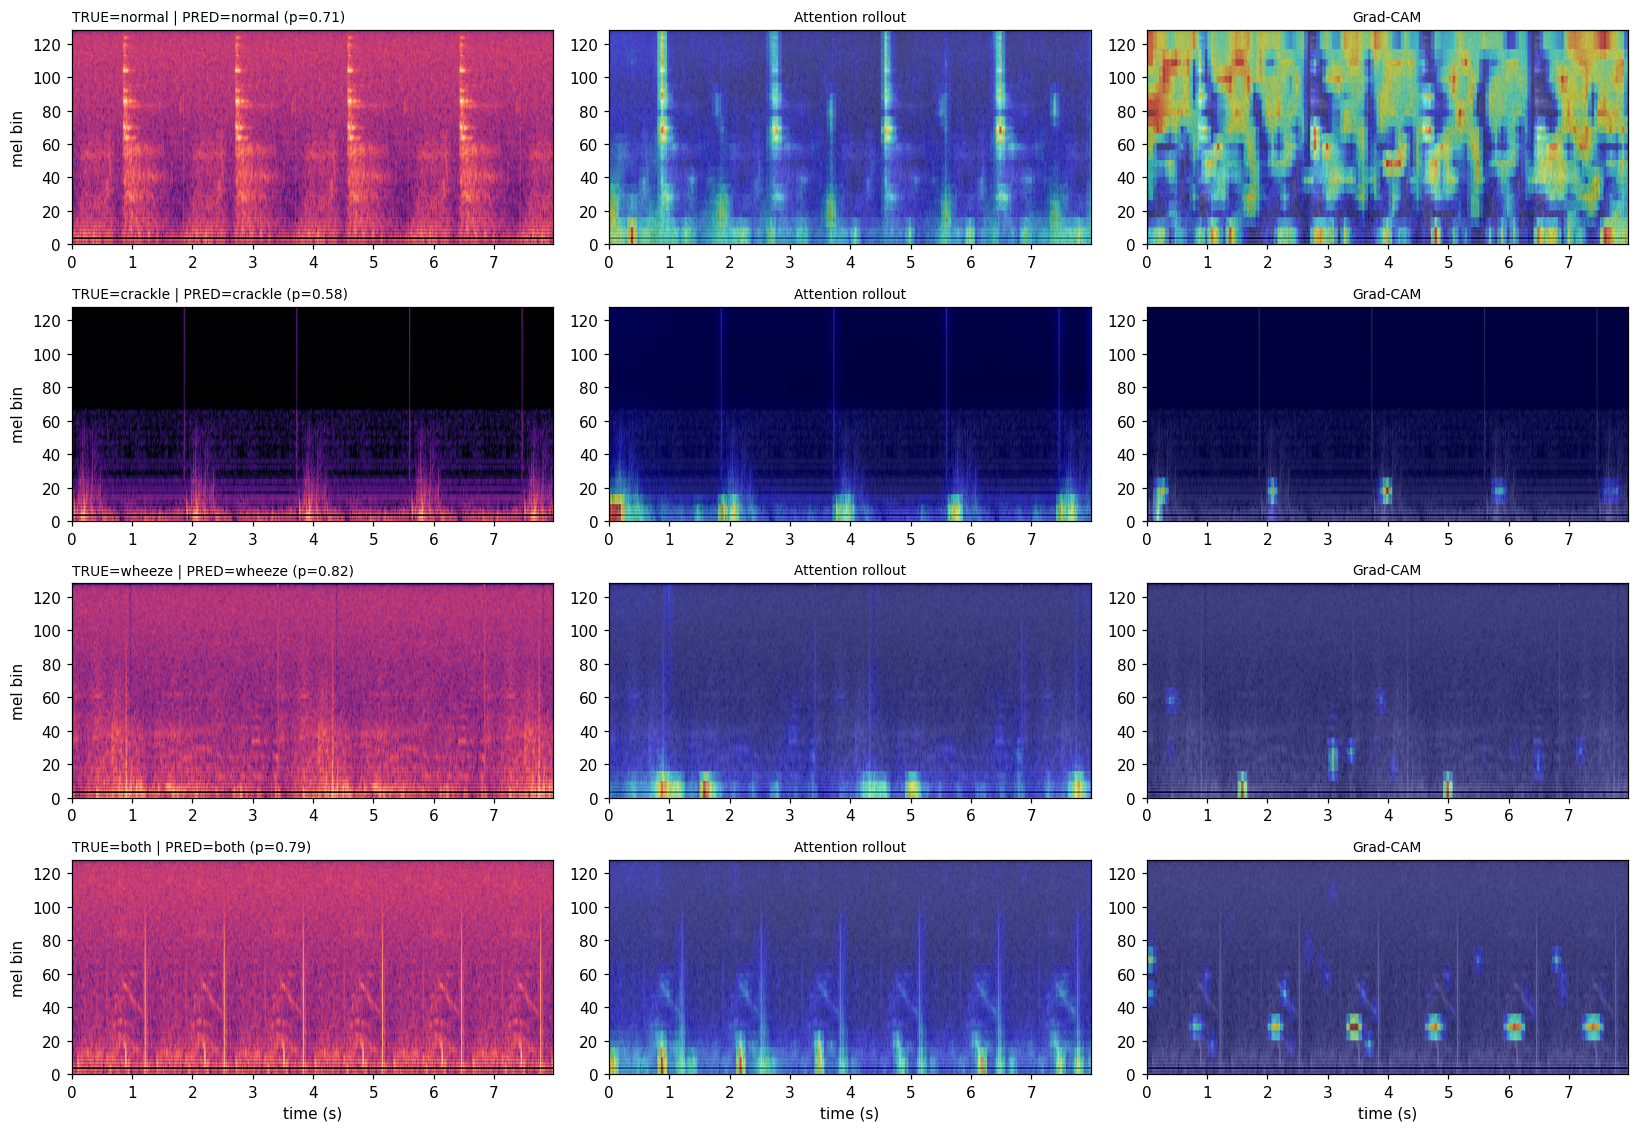

In [9]:
def get_item(idx, with_gradcam=True):
    wave = waves[idx]
    x = features(wave).to(DEVICE)
    rmap, probs = compute_rollout_map(model, x)
    gmap = compute_gradcam_map(model, x)[0] if with_gradcam else None
    return {"x": x[0].cpu().numpy(), "rollout": rmap, "gradcam": gmap, "probs": probs,
            "n_frames": n_real_frames(len(wave))}

def plot_items(items, titles, fname):
    rows = len(items)
    fig, axes = plt.subplots(rows, 3, figsize=(15, 2.6 * rows), squeeze=False)
    for r, (it, title) in enumerate(zip(items, titles)):
        nf = it["n_frames"]; extent = [0, nf * FRAME_SHIFT_S, 0, N_MELS]
        spec = it["x"][:nf].T
        axes[r, 0].imshow(spec, origin="lower", aspect="auto", cmap="magma", extent=extent)
        axes[r, 0].set_title(title, fontsize=9, loc="left")
        for c, key, name in [(1, "rollout", "Attention rollout"), (2, "gradcam", "Grad-CAM")]:
            axes[r, c].imshow(spec, origin="lower", aspect="auto", cmap="gray", extent=extent)
            if it[key] is not None:
                axes[r, c].imshow(normalize01(it[key][:, :nf]), origin="lower", aspect="auto",
                                  cmap="jet", alpha=0.5, extent=extent)
            axes[r, c].set_title(name, fontsize=9)
        axes[r, 0].set_ylabel("mel bin")
        for c in range(3): axes[r, c].set_xlabel("time (s)") if r == rows - 1 else None
    plt.tight_layout(); plt.savefig(FIG_DIR / fname, dpi=150); plt.show()

# --- correctly classified, highest-confidence example per class ---
picked, titles = [], []
for lab in LABELS:
    sub = test_df[(test_df["label"] == lab) & test_df["correct"]].sort_values("conf", ascending=False)
    if len(sub):
        idx = sub.index[0]; picked.append(idx)
        titles.append(f"TRUE={lab} | PRED={test_df.loc[idx,'pred']} (p={test_df.loc[idx,'conf']:.2f})")
plot_items([get_item(i) for i in picked], titles, "heatmaps_correct.png")

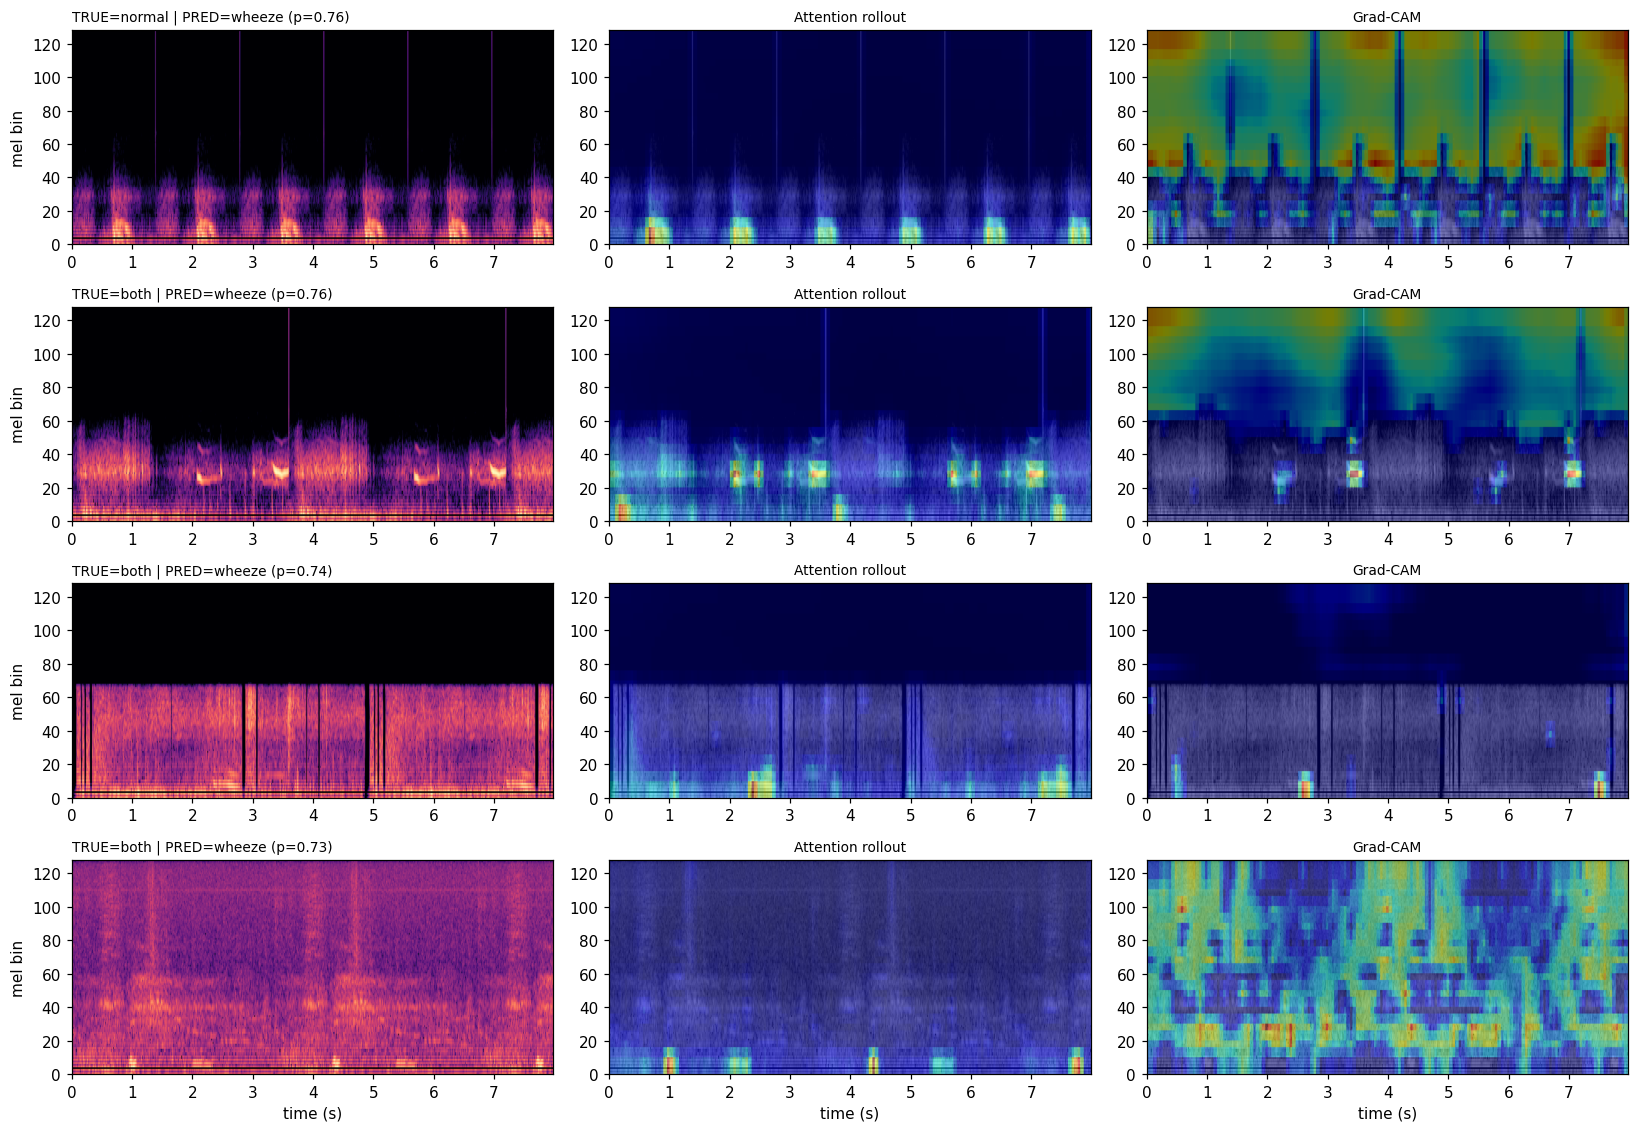

In [10]:
# --- confident mistakes (worth showing honestly in the write-up) ---
wrong = test_df[~test_df["correct"]].sort_values("conf", ascending=False).head(4)
if len(wrong):
    plot_items([get_item(i) for i in wrong.index],
               [f"TRUE={test_df.loc[i,'label']} | PRED={test_df.loc[i,'pred']} (p={test_df.loc[i,'conf']:.2f})" for i in wrong.index],
               "heatmaps_errors.png")

## **9. Per-Class Frequency Profile**

For each respiratory sound class, average the **Attention Rollout** maps across multiple correctly classified test cycles, considering only real (non-padded) frames.

This produces a frequency profile showing which **mel-frequency regions** receive greater attention for each class. Aggregating multiple samples provides a more stable interpretation than relying on a single heatmap.

> **Note:** Mel bins are perceptually spaced rather than linearly spaced in Hz, with finer resolution at lower frequencies.


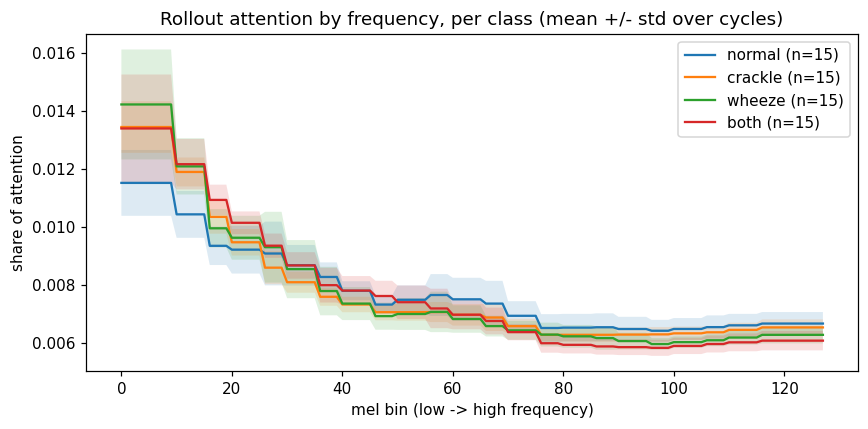

In [11]:
profiles = {}
for lab in LABELS:
    sub = test_df[(test_df["label"] == lab) & test_df["correct"]].sort_values("conf", ascending=False).head(N_PROFILE_PER_CLASS)
    curves = []
    for i in sub.index:
        it = get_item(i, with_gradcam=False)
        curve = it["rollout"][:, :it["n_frames"]].mean(axis=1)
        curves.append(curve / curve.sum())
    if curves:
        profiles[lab] = np.array(curves)

fig, ax = plt.subplots(figsize=(8, 4))
for lab, arr in profiles.items():
    m, s = arr.mean(0), arr.std(0)
    ax.plot(m, label=f"{lab} (n={len(arr)})"); ax.fill_between(range(N_MELS), m - s, m + s, alpha=0.15)
ax.set_xlabel("mel bin (low -> high frequency)"); ax.set_ylabel("share of attention")
ax.set_title("Rollout attention by frequency, per class (mean +/- std over cycles)")
ax.legend(); plt.tight_layout(); plt.savefig(FIG_DIR / "frequency_profile.png", dpi=150); plt.show()

## **10. Clean vs. noisy input**

Same cycle, three noise conditions. Two things to look at: does the prediction change, and does the heatmap drift toward broadband/diffuse attention as noise rises?

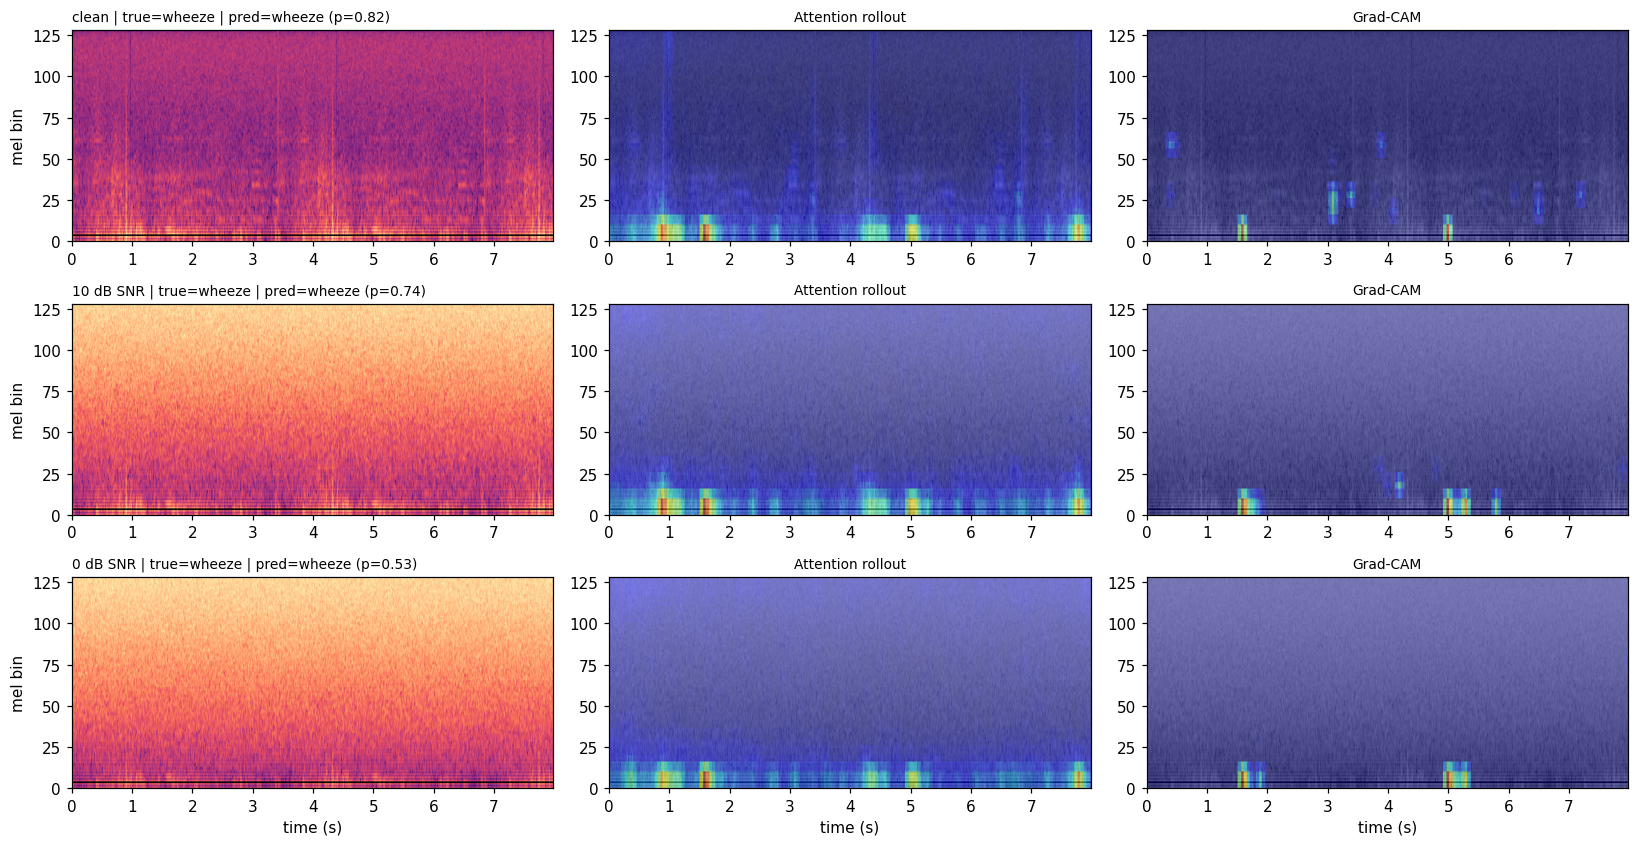

In [12]:
def add_noise_at_snr(signal, snr_db, rng):
    if snr_db is None:
        return signal
    sp = np.mean(signal.astype(np.float64) ** 2)
    noise = rng.standard_normal(len(signal))
    scale = np.sqrt(sp / (10 ** (snr_db / 10)) / np.mean(noise ** 2))
    return (signal + scale * noise).astype(np.float32)

abn = test_df[(test_df["label"] != "normal") & test_df["correct"]].sort_values("conf", ascending=False)
idx = abn.index[0]; rng = np.random.default_rng(SEED)
items, titles = [], []
for snr in NOISE_SNRS_DB:
    noisy = add_noise_at_snr(waves[idx], snr, rng)
    x = features(noisy).to(DEVICE)
    rmap, probs = compute_rollout_map(model, x)
    gmap, _ = compute_gradcam_map(model, x)
    items.append({"x": x[0].cpu().numpy(), "rollout": rmap, "gradcam": gmap, "probs": probs, "n_frames": n_real_frames(len(noisy))})
    titles.append(f"{'clean' if snr is None else f'{snr} dB SNR'} | true={test_df.loc[idx,'label']} | pred={LABELS[int(probs.argmax())]} (p={probs.max():.2f})")
plot_items(items, titles, "heatmaps_noise.png")

## **11. Randomization Sanity Check**

This experiment evaluates whether the generated attention maps depend on the **learned model parameters**.

A randomly initialized model with the same architecture is used to generate a rollout map for the same input cycle. The randomized and trained-model maps are then compared.

If the maps are highly similar, the visualization may be driven primarily by **input structure or padding** rather than learned representations.

This follows the model-randomization sanity-check approach described by Adebayo et al. (2018). The similarity measure is treated as a **diagnostic**, not as a universal pass/fail criterion.


Correlation between trained-model and random-model rollout maps: 0.359


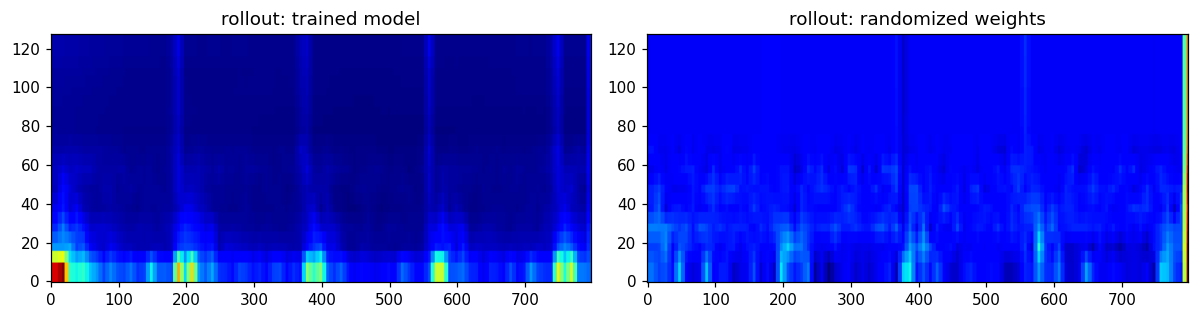

In [13]:
rand_model = ASTForAudioClassification(model.config).to(DEVICE).eval()   # random init, same architecture
check_idx = picked[min(1, len(picked) - 1)]
x = features(waves[check_idx]).to(DEVICE); nf = n_real_frames(len(waves[check_idx]))

trained_map, _ = compute_rollout_map(model, x)
rand_map, _ = compute_rollout_map(rand_model, x)
corr = np.corrcoef(trained_map[:, :nf].ravel(), rand_map[:, :nf].ravel())[0, 1]
print(f"Correlation between trained-model and random-model rollout maps: {corr:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
for ax, m, t in zip(axes, [trained_map, rand_map], ["trained model", "randomized weights"]):
    ax.imshow(normalize01(m[:, :nf]), origin="lower", aspect="auto", cmap="jet"); ax.set_title(f"rollout: {t}")
plt.tight_layout(); plt.savefig(FIG_DIR / "sanity_randomization.png", dpi=150); plt.show()
del rand_model; torch.cuda.empty_cache()

## **12. Export the Checkpoint for Deployment (FP16) + Parity Check**

Export the trained AST checkpoint in **FP16 precision** to reduce its storage footprint from approximately **340 MB to 170 MB**.

The demo application loads the checkpoint in **FP32** for inference. Since FP16 conversion introduces small numerical differences, the exported model is compared with the original FP32 model.

The parity check verifies that both models produce the **same predicted class for the first 200 test cycles** before deployment.


In [14]:
fp16_state = {k: (v.half() if v.is_floating_point() else v) for k, v in model.state_dict().items()}
EXPORT_PATH = OUT_DIR / "ast_lung_fp16.pt"
torch.save(fp16_state, EXPORT_PATH)
print(f"Saved {EXPORT_PATH.name}: {EXPORT_PATH.stat().st_size / 1e6:.0f} MB")

roundtrip = ASTForAudioClassification(model.config).to(DEVICE).eval()
roundtrip.load_state_dict({k: (v.float() if v.is_floating_point() else v) for k, v in
                           torch.load(EXPORT_PATH, map_location=DEVICE).items()})

n = min(200, len(waves)); agree = 0
for i in range(0, n, 16):
    batch = fe(waves[i:min(i + 16, n)], sampling_rate=TARGET_SR, return_tensors="pt")["input_values"].to(DEVICE)
    with torch.no_grad():
        a = model(input_values=batch).logits.argmax(-1); b = roundtrip(input_values=batch).logits.argmax(-1)
    agree += (a == b).sum().item()
print(f"fp32 vs exported-fp16 agreement on {n} test cycles: {agree / n * 100:.1f}%")
assert agree / n >= 0.98, "Exported model disagrees too often -- keep fp32 instead (drop the .half())."
del roundtrip; torch.cuda.empty_cache()

Saved ast_lung_fp16.pt: 172 MB
fp32 vs exported-fp16 agreement on 200 test cycles: 100.0%
